<a href="https://colab.research.google.com/github/aakaanksharegula10-dotcom/Dissertation/blob/main/silver_price_forecasting_FIXED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Time Series Modelling and Forecast Evaluation of Silver Prices
## Using Historical Data and Machine Learning Techniques
### LD7083 — Computing and Digital Technologies Project Dissertation

**Models Implemented:** ARIMA | Facebook Prophet | LSTM | Hybrid ARIMA-LSTM  
**Evaluation Metrics:** RMSE | MAPE  
**Dataset:** ~10 years daily silver price data

---

## 0. Import Libraries and Setup

In [ ]:
# ─── Install required packages (run once) ─────────────────────────────────────
!pip install -q prophet statsmodels scikit-learn tensorflow
print('All packages installed.')

All packages installed.


In [ ]:
# ─── Standard Libraries ───────────────────────────────────────────────────────
import os
import warnings
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# ─── Statistical / Time Series ────────────────────────────────────────────────
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm

# ─── Prophet ──────────────────────────────────────────────────────────────────
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly

# ─── Machine Learning ─────────────────────────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# ─── Deep Learning ────────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ─── Settings ─────────────────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)

plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'lines.linewidth': 1.8
})

COLORS = {
    'actual':  '#2c3e50',
    'arima':   '#e74c3c',
    'prophet': '#f39c12',
    'lstm':    '#27ae60',
    'hybrid':  '#8e44ad'
}

print('All libraries imported successfully.')
print(f'TensorFlow version: {tf.__version__}')

All libraries imported successfully.
TensorFlow version: 2.20.0


---
## 1. Data Loading
### 1.1 Extract and Load Dataset from ZIP

In [ ]:
# ─── Extract ZIP ──────────────────────────────────────────────────────────────
# Auto-detect any uploaded ZIP in /content/
import glob
zip_candidates = glob.glob('/content/*.zip')
if not zip_candidates:
    raise FileNotFoundError('No ZIP found in /content/. Upload archive.zip to Colab first.')
ZIP_PATH = zip_candidates[0]
print(f'Using ZIP: {ZIP_PATH}')
EXTRACT_DIR = 'data'

os.makedirs(EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_DIR)
    extracted = z.namelist()

print('Files extracted from ZIP:')
for f in extracted:
    print(f'  - {f}')

Using ZIP: /content/archive.zip
Files extracted from ZIP:
  - Gold Futures Historical Data (23.01.24-22.11.24).csv
  - Gold prices (18.08.2023 - 22.01.2024).xlsx
  - Silver Futures Historical Data (23.01.24-22.11.24).csv
  - Silver prices (18.08.2023 - 22.01.2024).xlsx
  - gold prices.csv
  - silver prices.csv


In [ ]:
# ─── Load Primary Dataset: ~10-year daily silver prices ───────────────────────
SILVER_PATH = os.path.join(EXTRACT_DIR, 'silver prices.csv')

df_raw = pd.read_csv(SILVER_PATH)
print('Raw shape:', df_raw.shape)
print('\nFirst 5 rows:')
df_raw.head()

Raw shape: (2539, 6)

First 5 rows:


,Date,Close/Last,Volume,Open,High,Low
0,08/17/2023,23.042,11441.0,22.800,23.385,22.725
1,08/16/2023,22.856,10802.0,22.905,23.170,22.770
2,08/15/2023,22.656,60396.0,22.650,22.770,22.265
3,08/14/2023,22.708,51908.0,22.740,22.820,22.410
4,08/11/2023,22.743,48043.0,22.760,22.910,22.610


In [ ]:
# ─── Load Supplementary Dataset: Silver Futures (Jan-Nov 2024) ────────────────
FUTURES_PATH = os.path.join(EXTRACT_DIR, 'Silver Futures Historical Data (23.01.24-22.11.24).csv')

df_futures_raw = pd.read_csv(FUTURES_PATH)
print('Futures data shape:', df_futures_raw.shape)
print('\nFirst 5 rows:')
df_futures_raw.head()

Futures data shape: (222, 7)

First 5 rows:


,Date,Price,Open,High,Low,Vol.,Change %
0,11/22/2024,31.422,30.815,31.453,30.810,NaN,1.55%
1,11/21/2024,30.943,30.955,31.380,30.715,62.74K,-0.20%
2,11/20/2024,31.005,31.305,31.420,30.860,56.01K,-0.82%
3,11/19/2024,31.262,31.245,31.615,31.125,60.77K,0.12%
4,11/18/2024,31.224,30.370,31.355,30.350,57.05K,2.60%


---
## 2. Data Preprocessing (Chapter 3.4 & Figure 4.1, 4.2, 4.3)
### 2.1 Parse and Clean Primary Silver Dataset

In [ ]:
# ─── Parse Dates and Close Price ──────────────────────────────────────────────
df = df_raw.copy()
df.columns = df.columns.str.strip()

# Rename Close/Last → Close
df.rename(columns={'Close/Last': 'Close'}, inplace=True)

df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')
df.sort_values('Date', inplace=True)
df.reset_index(drop=True, inplace=True)

# Keep only Date and Close price
df = df[['Date', 'Close']].copy()
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')

print('Dataset Summary')
print('---------------')
print(f'Date range : {df["Date"].min().date()}  →  {df["Date"].max().date()}')
print(f'Total rows : {len(df)}')
print(f'Missing    : {df["Close"].isna().sum()}')
print(f'Duplicates : {df.duplicated("Date").sum()}')
df.tail()

Dataset Summary
---------------
Date range : 2013-08-19  →  2023-08-17
Total rows : 2539
Missing    : 0
Duplicates : 0


,Date,Close
2534,2023-08-11,22.743
2535,2023-08-14,22.708
2536,2023-08-15,22.656
2537,2023-08-16,22.856
2538,2023-08-17,23.042


In [ ]:
# ─── Handle Missing Values and Duplicates ─────────────────────────────────────
# Forward-fill missing (weekend/holiday gaps)
df['Close'] = df['Close'].ffill()
df.drop_duplicates(subset='Date', keep='last', inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'After cleaning: {len(df)} records, {df["Close"].isna().sum()} missing values')

# Statistical summary
print('\nDescriptive Statistics:')
df['Close'].describe().round(4)

After cleaning: 2539 records, 0 missing values

Descriptive Statistics:


,Close
count,2539.0000
mean,19.1321
std,3.7502
min,11.7720
25%,16.2650
50%,17.8150
75%,22.1045
max,29.4180


### Figure 4.1 — Original Silver Price Time Series (Raw Data)

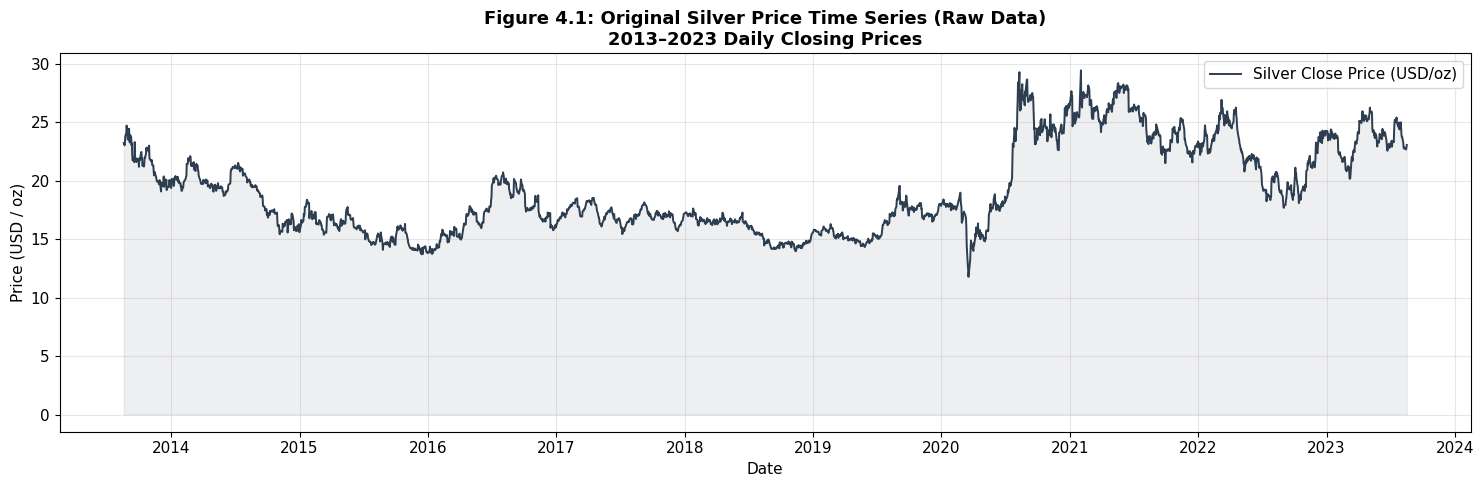

Key observations: Clear trend shifts in 2020 (COVID spike) and 2022 (market correction).


In [ ]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(df['Date'], df['Close'], color=COLORS['actual'], linewidth=1.4, label='Silver Close Price (USD/oz)')
ax.fill_between(df['Date'], df['Close'], alpha=0.08, color=COLORS['actual'])
ax.set_title('Figure 4.1: Original Silver Price Time Series (Raw Data)\n2013–2023 Daily Closing Prices', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD / oz)')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend()
plt.tight_layout()
plt.savefig('fig4_1_raw_series.png', dpi=150)
plt.show()
print('Key observations: Clear trend shifts in 2020 (COVID spike) and 2022 (market correction).')

### 2.2 Outlier Analysis

In [ ]:
# ─── IQR-based Outlier Detection ──────────────────────────────────────────────
Q1 = df['Close'].quantile(0.25)
Q3 = df['Close'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
outliers = df[(df['Close'] < lower) | (df['Close'] > upper)]
print(f'IQR bounds: [{lower:.2f}, {upper:.2f}]')
print(f'Outlier records detected: {len(outliers)}')
print('\nOutlier dates (potential market events):')
print(outliers[['Date','Close']].to_string(index=False))

IQR bounds: [7.51, 30.86]
Outlier records detected: 0

Outlier dates (potential market events):
Empty DataFrame
Columns: [Date, Close]
Index: []


### Figure 4.2 — Cleaned and Preprocessed Time Series

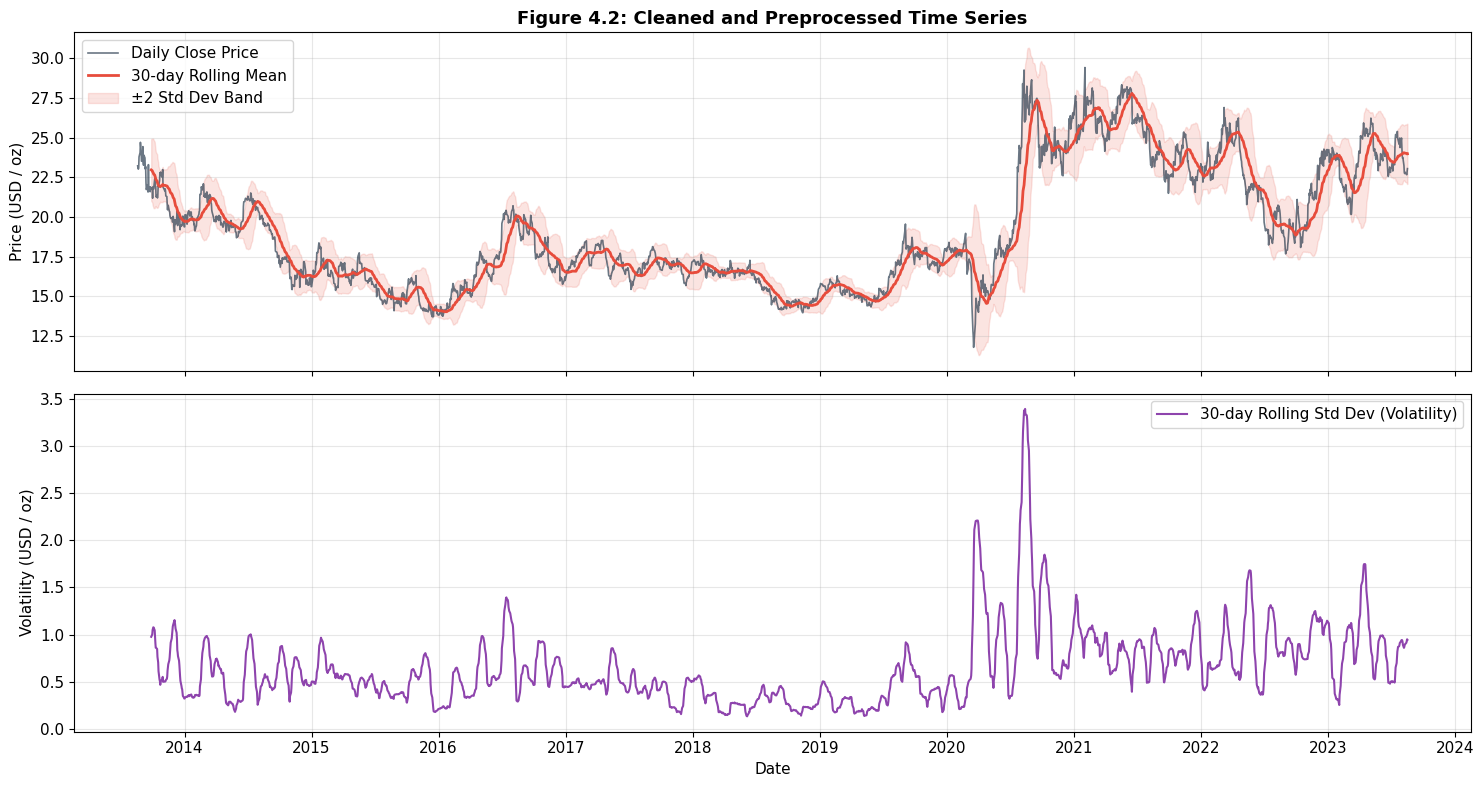

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# Top: price with rolling statistics
rolling_mean = df['Close'].rolling(window=30).mean()
rolling_std  = df['Close'].rolling(window=30).std()

axes[0].plot(df['Date'], df['Close'], color=COLORS['actual'], linewidth=1.2, alpha=0.7, label='Daily Close Price')
axes[0].plot(df['Date'], rolling_mean, color='#e74c3c', linewidth=2, label='30-day Rolling Mean')
axes[0].fill_between(df['Date'],
                     rolling_mean - 2*rolling_std,
                     rolling_mean + 2*rolling_std,
                     alpha=0.15, color='#e74c3c', label='±2 Std Dev Band')
axes[0].set_title('Figure 4.2: Cleaned and Preprocessed Time Series', fontweight='bold')
axes[0].set_ylabel('Price (USD / oz)')
axes[0].legend()

# Bottom: rolling volatility
axes[1].plot(df['Date'], rolling_std, color='#8e44ad', linewidth=1.5, label='30-day Rolling Std Dev (Volatility)')
axes[1].set_ylabel('Volatility (USD / oz)')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('fig4_2_cleaned_series.png', dpi=150)
plt.show()

### 2.3 Normalisation (for LSTM) — Figure 4.3

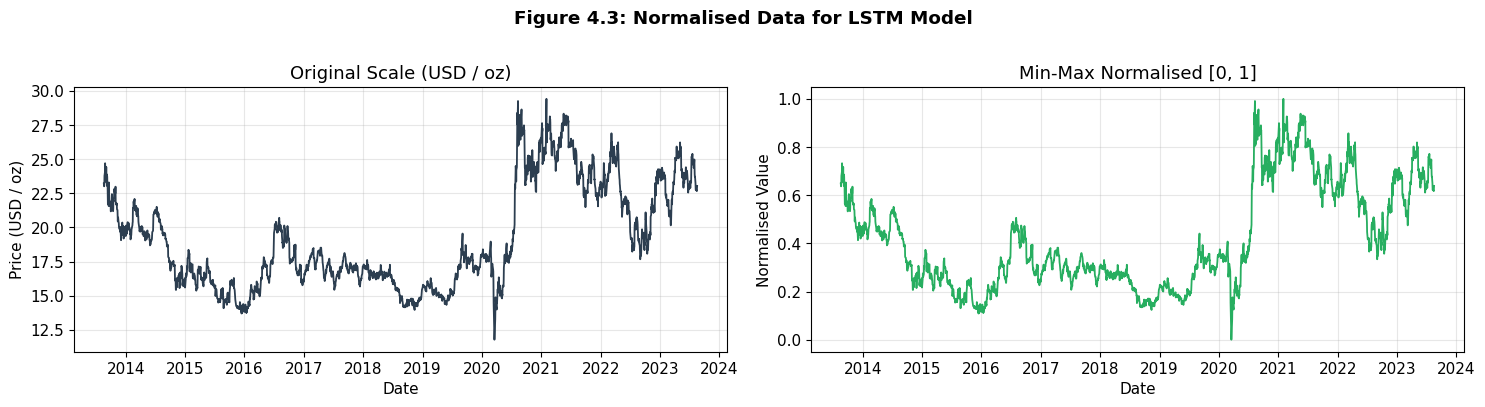

Min-Max Scaling applied: range [0, 1] — prevents large-magnitude features dominating LSTM training.


In [ ]:
# ─── Min-Max Normalisation ────────────────────────────────────────────────────
scaler = MinMaxScaler(feature_range=(0, 1))
df['Close_Norm'] = scaler.fit_transform(df[['Close']])

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes[0].plot(df['Date'], df['Close'], color=COLORS['actual'], linewidth=1.3)
axes[0].set_title('Original Scale (USD / oz)')
axes[0].set_ylabel('Price (USD / oz)')
axes[0].set_xlabel('Date')

axes[1].plot(df['Date'], df['Close_Norm'], color='#27ae60', linewidth=1.3)
axes[1].set_title('Min-Max Normalised [0, 1]')
axes[1].set_ylabel('Normalised Value')
axes[1].set_xlabel('Date')

plt.suptitle('Figure 4.3: Normalised Data for LSTM Model', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig4_3_normalised.png', dpi=150)
plt.show()
print('Min-Max Scaling applied: range [0, 1] — prevents large-magnitude features dominating LSTM training.')

### 2.4 Train-Test Split

Training set : 2031 records  (2013-08-19 → 2021-08-10)
Test set     : 508  records  (2021-08-11 → 2023-08-17)


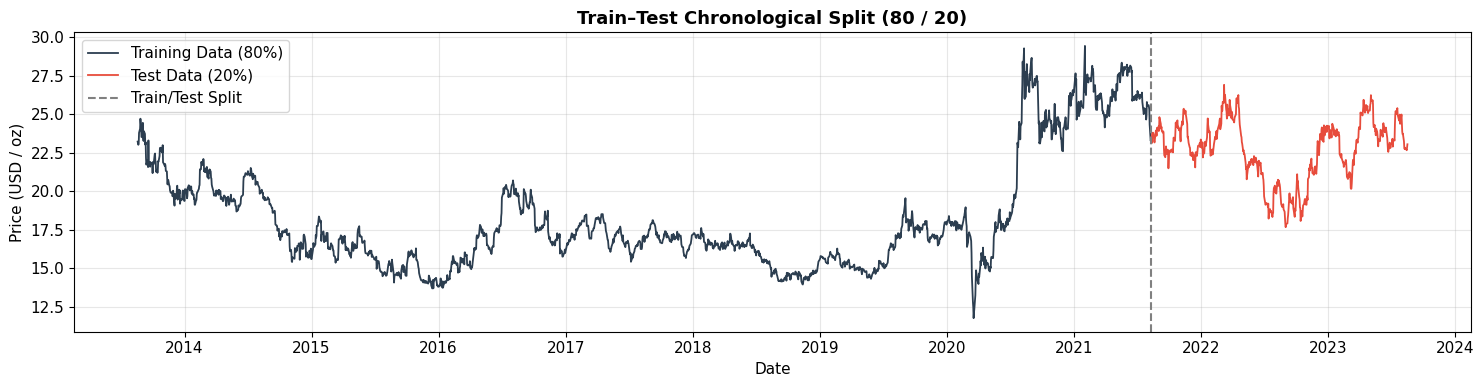

In [ ]:
# ─── Chronological 80 / 20 Split ─────────────────────────────────────────────
SPLIT_RATIO = 0.80
split_idx   = int(len(df) * SPLIT_RATIO)

train_df = df.iloc[:split_idx].copy()
test_df  = df.iloc[split_idx:].copy()

print(f'Training set : {len(train_df)} records  ({train_df["Date"].min().date()} → {train_df["Date"].max().date()})')
print(f'Test set     : {len(test_df)}  records  ({test_df["Date"].min().date()} → {test_df["Date"].max().date()})')

# Quick visualisation of split
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(train_df['Date'], train_df['Close'], color=COLORS['actual'], linewidth=1.3, label='Training Data (80%)')
ax.plot(test_df['Date'],  test_df['Close'],  color=COLORS['arima'],  linewidth=1.3, label='Test Data (20%)')
ax.axvline(x=train_df['Date'].iloc[-1], color='grey', linestyle='--', linewidth=1.5, label='Train/Test Split')
ax.set_title('Train–Test Chronological Split (80 / 20)', fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Price (USD / oz)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 3. Stationarity Analysis (Chapter 3.4.2 & Figures 4.4, 4.5, 4.6)

In [ ]:
# ─── ADF Test Function ────────────────────────────────────────────────────────
def adf_test(series, title=''):
    result = adfuller(series.dropna())
    labels = ['ADF Statistic', 'p-value', '# Lags Used', '# Observations']
    print(f'\n══ ADF Test: {title} ══')
    for l, v in zip(labels, result[:4]):
        print(f'  {l:<22}: {v:.6f}')
    for k, v in result[4].items():
        print(f'  Critical Value ({k}) : {v:.4f}')
    decision = 'STATIONARY ✓' if result[1] < 0.05 else 'NON-STATIONARY ✗'
    print(f'  → Series is {decision} (p = {result[1]:.4f})')
    return result[1] < 0.05

# Test original series
is_stationary = adf_test(train_df['Close'], 'Original Silver Prices')


══ ADF Test: Original Silver Prices ══
  ADF Statistic         : -1.649108
  p-value               : 0.457506
  # Lags Used           : 26.000000
  # Observations        : 2004.000000
  Critical Value (1%) : -3.4336
  Critical Value (5%) : -2.8630
  Critical Value (10%) : -2.5675
  → Series is NON-STATIONARY ✗ (p = 0.4575)


### Figure 4.4 — Time Series Before Differencing

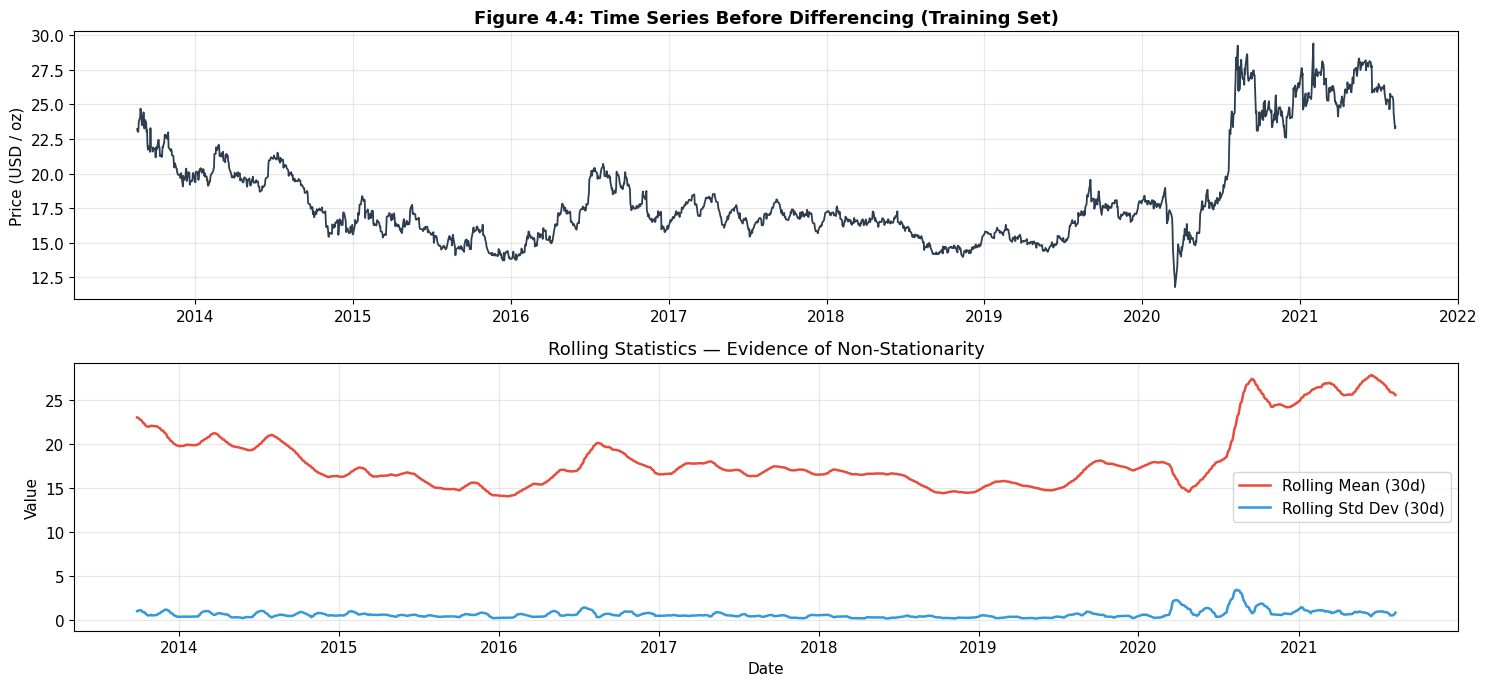

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(15, 7))

axes[0].plot(train_df['Date'], train_df['Close'], color=COLORS['actual'], linewidth=1.3)
axes[0].set_title('Figure 4.4: Time Series Before Differencing (Training Set)', fontweight='bold')
axes[0].set_ylabel('Price (USD / oz)')

# Rolling mean and std
r_mean = train_df['Close'].rolling(30).mean()
r_std  = train_df['Close'].rolling(30).std()
axes[1].plot(train_df['Date'], r_mean, color='#e74c3c', label='Rolling Mean (30d)')
axes[1].plot(train_df['Date'], r_std,  color='#3498db', label='Rolling Std Dev (30d)')
axes[1].set_title('Rolling Statistics — Evidence of Non-Stationarity')
axes[1].set_ylabel('Value')
axes[1].set_xlabel('Date')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig4_4_before_diff.png', dpi=150)
plt.show()

### Figure 4.5 — Time Series After Differencing


══ ADF Test: 1st-Order Differenced Silver Prices ══
  ADF Statistic         : -9.528749
  p-value               : 0.000000
  # Lags Used           : 25.000000
  # Observations        : 2004.000000
  Critical Value (1%) : -3.4336
  Critical Value (5%) : -2.8630
  Critical Value (10%) : -2.5675
  → Series is STATIONARY ✓ (p = 0.0000)


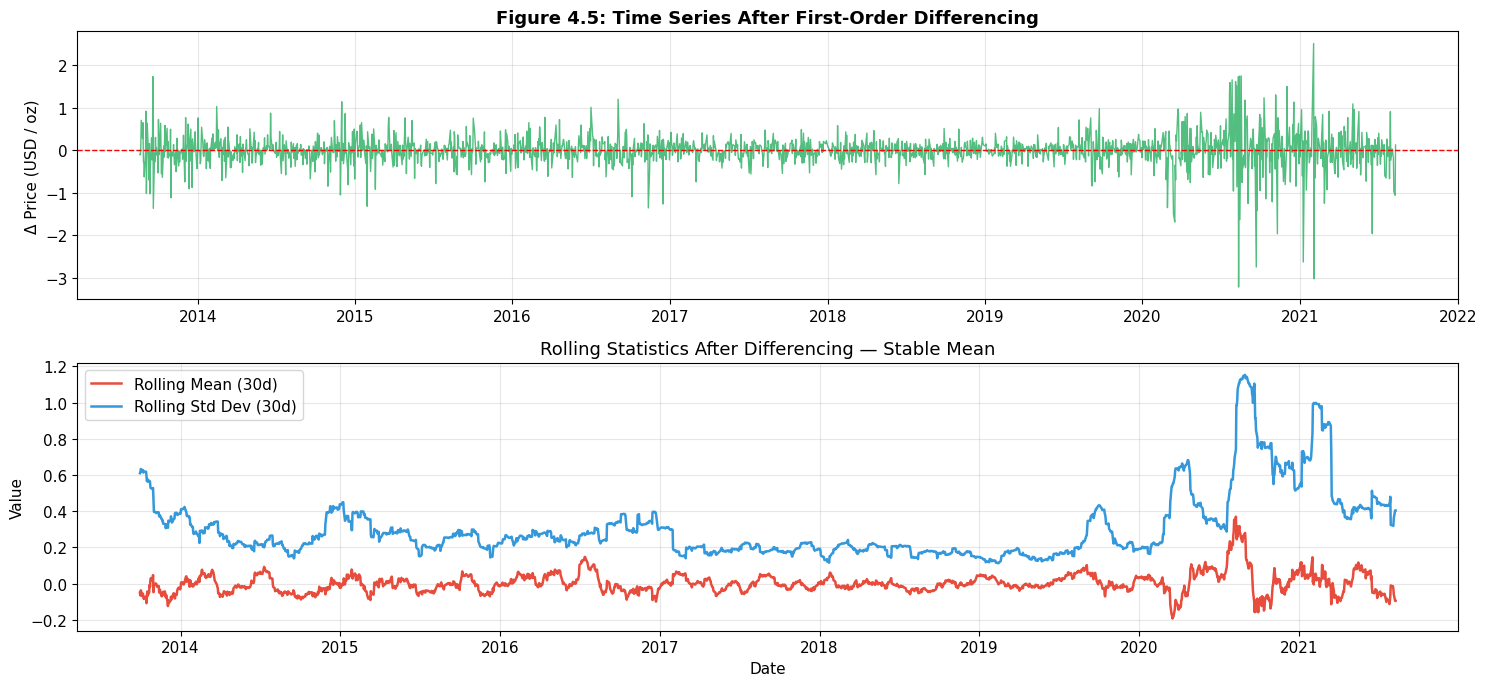

In [ ]:
# ─── First-order Differencing ─────────────────────────────────────────────────
diff_series = train_df['Close'].diff().dropna()
diff_dates  = train_df['Date'].iloc[1:]

adf_test(diff_series, '1st-Order Differenced Silver Prices')

fig, axes = plt.subplots(2, 1, figsize=(15, 7))

axes[0].plot(diff_dates, diff_series.values, color='#27ae60', linewidth=1, alpha=0.8)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Figure 4.5: Time Series After First-Order Differencing', fontweight='bold')
axes[0].set_ylabel('Δ Price (USD / oz)')

# Rolling stats of differenced series
r_mean_d = diff_series.rolling(30).mean()
r_std_d  = diff_series.rolling(30).std()
axes[1].plot(diff_dates, r_mean_d.values, color='#e74c3c', label='Rolling Mean (30d)')
axes[1].plot(diff_dates, r_std_d.values,  color='#3498db', label='Rolling Std Dev (30d)')
axes[1].set_title('Rolling Statistics After Differencing — Stable Mean')
axes[1].set_ylabel('Value')
axes[1].set_xlabel('Date')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig4_5_after_diff.png', dpi=150)
plt.show()

### Figure 4.6 — ACF and PACF Plots

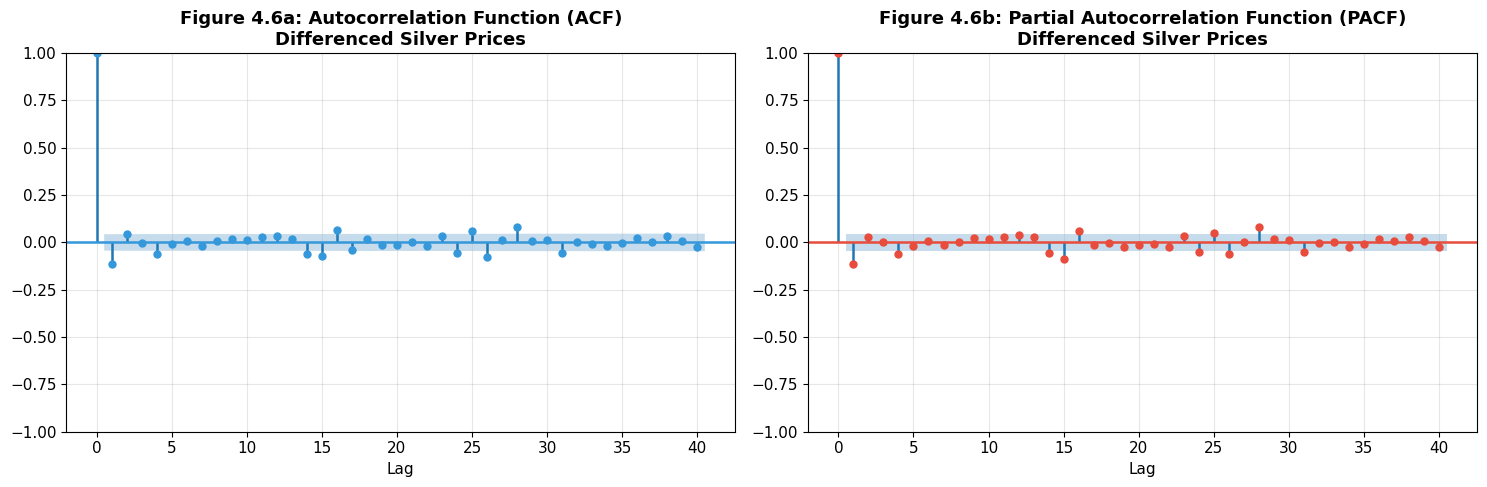

ACF/PACF interpretation: Significant spike at lag 1 in PACF → AR(1) component. Cutoff after lag 1 in ACF → MA(1). Suggests ARIMA(1,1,1) as starting point.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

plot_acf(diff_series, lags=40, ax=axes[0], color='#3498db', alpha=0.05)
axes[0].set_title('Figure 4.6a: Autocorrelation Function (ACF)\nDifferenced Silver Prices', fontweight='bold')
axes[0].set_xlabel('Lag')

plot_pacf(diff_series, lags=40, ax=axes[1], color='#e74c3c', alpha=0.05, method='ywm')
axes[1].set_title('Figure 4.6b: Partial Autocorrelation Function (PACF)\nDifferenced Silver Prices', fontweight='bold')
axes[1].set_xlabel('Lag')

plt.tight_layout()
plt.savefig('fig4_6_acf_pacf.png', dpi=150)
plt.show()
print('ACF/PACF interpretation: Significant spike at lag 1 in PACF → AR(1) component. Cutoff after lag 1 in ACF → MA(1). Suggests ARIMA(1,1,1) as starting point.')

---
## 4. Model 1 — ARIMA (Chapter 3.5.1 & Figure 4.7)

In [ ]:
# ─── ARIMA Parameter Selection using AIC ─────────────────────────────────────
print('Grid-searching ARIMA (p,d,q) parameters by AIC...')
best_aic = np.inf
best_order = None
results_grid = []

for p in range(0, 4):
    for q in range(0, 4):
        try:
            model = ARIMA(train_df['Close'], order=(p, 1, q))
            res   = model.fit()
            results_grid.append({'p': p, 'd': 1, 'q': q, 'AIC': res.aic, 'BIC': res.bic})
            if res.aic < best_aic:
                best_aic   = res.aic
                best_order = (p, 1, q)
        except:
            continue

grid_df = pd.DataFrame(results_grid).sort_values('AIC')
print(f'\nBest ARIMA order: {best_order}  |  AIC: {best_aic:.2f}')
print('\nTop 5 configurations:')
print(grid_df.head(5).to_string(index=False))

Grid-searching ARIMA (p,d,q) parameters by AIC...

Best ARIMA order: (3, 1, 2)  |  AIC: 1568.63

Top 5 configurations:
 p  d  q         AIC         BIC
 3  1  2 1568.630883 1602.325629
 3  1  3 1571.513496 1610.824034
 2  1  2 1573.280835 1601.359790
 1  1  0 1574.527908 1585.759490
 0  1  2 1574.615702 1591.463075


In [ ]:
# ─── Fit Best ARIMA Model ─────────────────────────────────────────────────────
arima_model = ARIMA(train_df['Close'], order=best_order)
arima_fit   = arima_model.fit()
print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2031
Model:                 ARIMA(3, 1, 2)   Log Likelihood                -778.315
Date:                Tue, 05 May 2026   AIC                           1568.631
Time:                        08:12:54   BIC                           1602.326
Sample:                             0   HQIC                          1580.994
                               - 2031                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6119      0.039     15.665      0.000       0.535       0.688
ar.L2         -0.8074      0.039    -20.843      0.000      -0.883      -0.731
ar.L3         -0.1355      0.012    -11.546      0.0

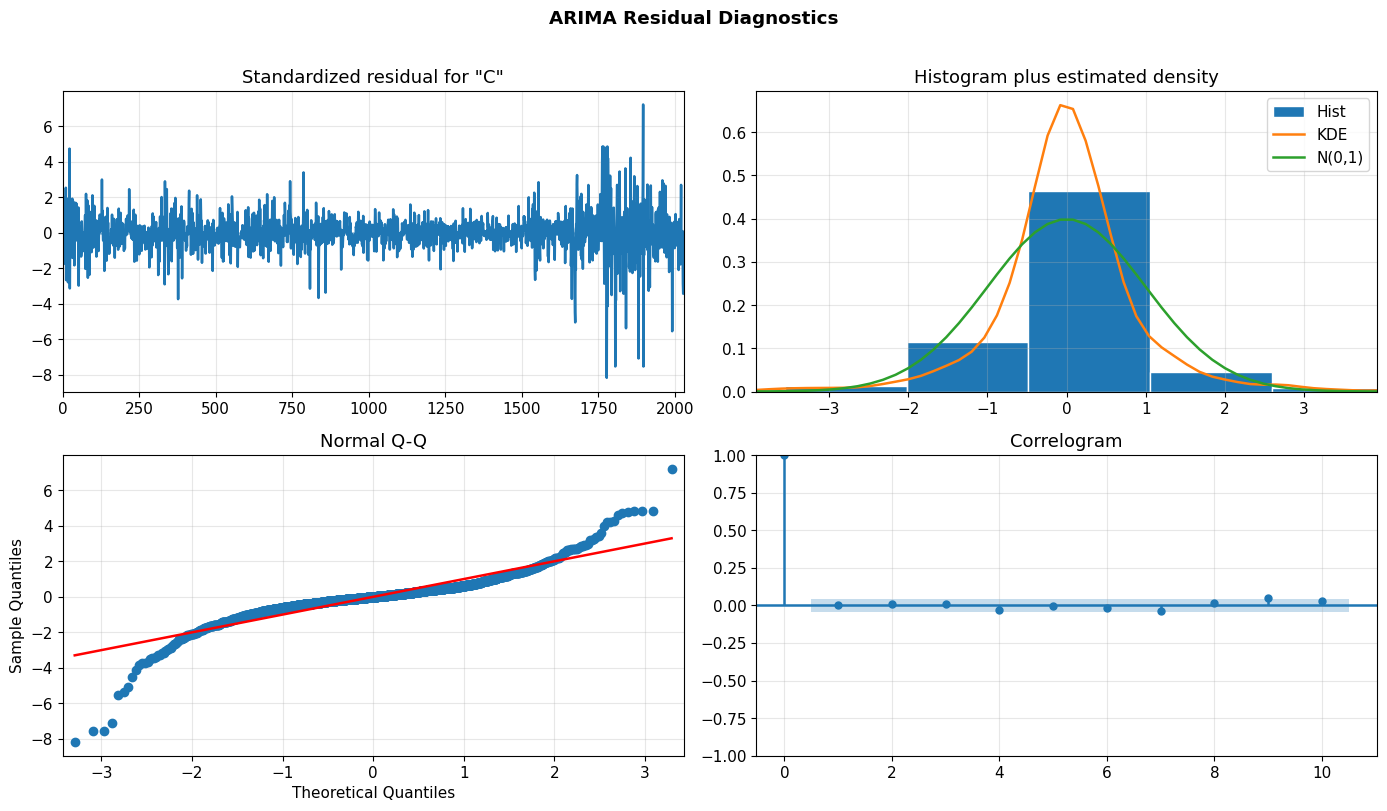

In [ ]:
# ─── ARIMA Residual Diagnostics ───────────────────────────────────────────────
fig = arima_fit.plot_diagnostics(figsize=(14, 8))
plt.suptitle('ARIMA Residual Diagnostics', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('arima_diagnostics.png', dpi=150)
plt.show()

In [ ]:
# ─── ARIMA Forecasting on Test Set ────────────────────────────────────────────
n_test = len(test_df)

# Rolling one-step-ahead forecast
arima_predictions = []
history = list(train_df['Close'])

for i in range(n_test):
    model = ARIMA(history, order=best_order)
    fitted = model.fit()
    yhat = fitted.forecast(steps=1)[0]
    arima_predictions.append(yhat)
    history.append(test_df['Close'].iloc[i])
    if (i+1) % 100 == 0:
        print(f'  ARIMA rolling forecast: step {i+1}/{n_test}')

arima_pred = np.array(arima_predictions)
arima_actual = test_df['Close'].values

# Metrics
arima_rmse = np.sqrt(mean_squared_error(arima_actual, arima_pred))
arima_mape = mean_absolute_percentage_error(arima_actual, arima_pred) * 100
print(f'\n══ ARIMA Performance ══')
print(f'  RMSE : {arima_rmse:.4f}')
print(f'  MAPE : {arima_mape:.2f}%')

  ARIMA rolling forecast: step 100/508
  ARIMA rolling forecast: step 200/508
  ARIMA rolling forecast: step 300/508
  ARIMA rolling forecast: step 400/508
  ARIMA rolling forecast: step 500/508

══ ARIMA Performance ══
  RMSE : 0.4049
  MAPE : 1.39%


### Figure 4.7 — ARIMA Forecast vs Actual Silver Prices

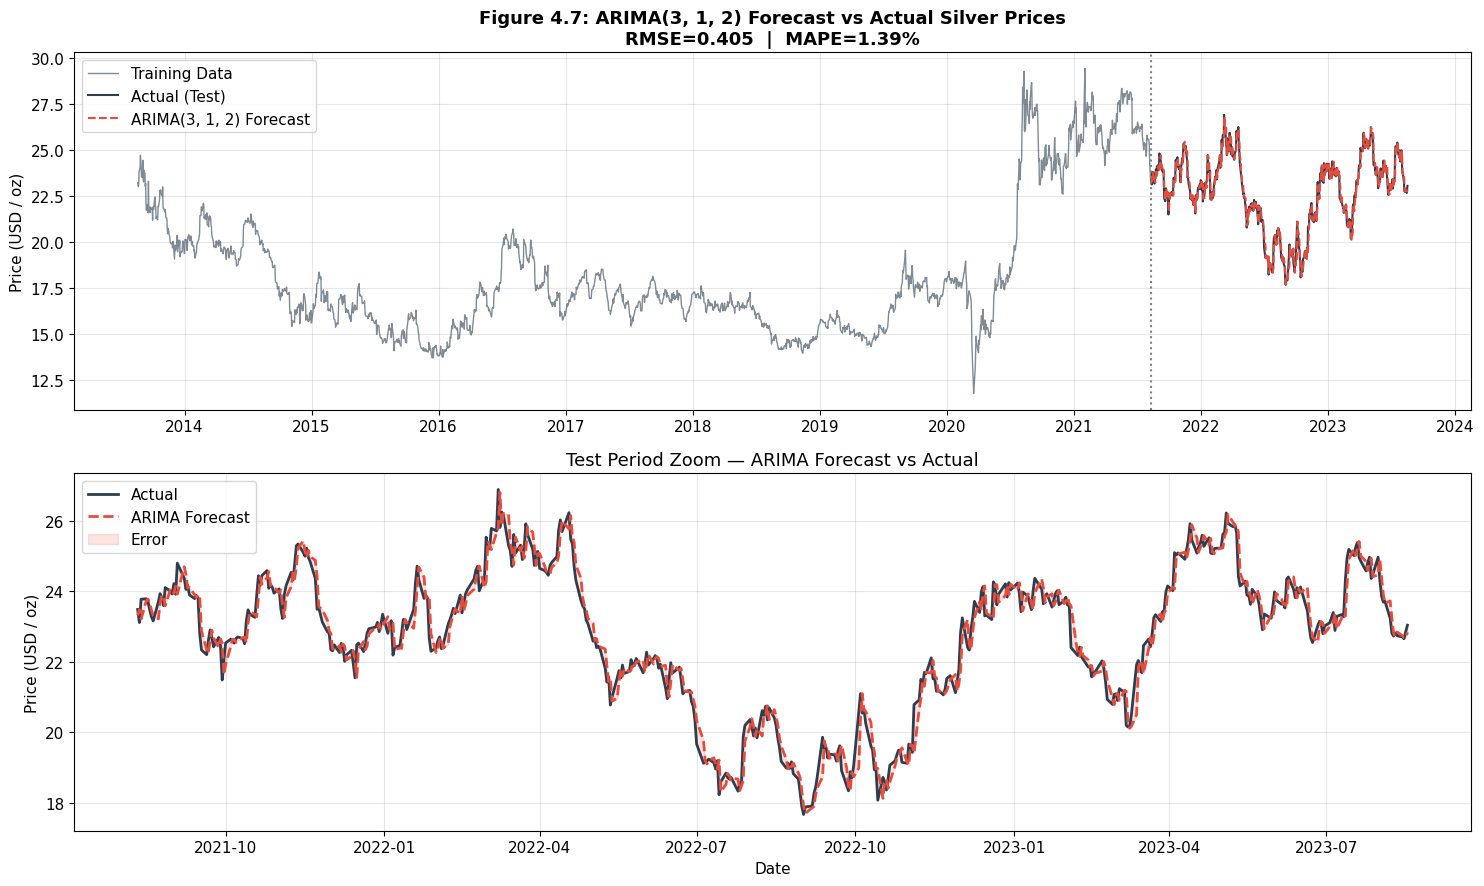

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(15, 9))

# Full time series + forecast window
axes[0].plot(train_df['Date'], train_df['Close'], color=COLORS['actual'], linewidth=1, alpha=0.6, label='Training Data')
axes[0].plot(test_df['Date'],  arima_actual,       color=COLORS['actual'], linewidth=1.5, label='Actual (Test)')
axes[0].plot(test_df['Date'],  arima_pred,          color=COLORS['arima'],  linewidth=1.5, linestyle='--', label=f'ARIMA{best_order} Forecast')
axes[0].axvline(x=train_df['Date'].iloc[-1], color='grey', linestyle=':', linewidth=1.5)
axes[0].set_title(f'Figure 4.7: ARIMA{best_order} Forecast vs Actual Silver Prices\nRMSE={arima_rmse:.3f}  |  MAPE={arima_mape:.2f}%', fontweight='bold')
axes[0].set_ylabel('Price (USD / oz)')
axes[0].legend()

# Forecast period zoom
axes[1].plot(test_df['Date'], arima_actual, color=COLORS['actual'], linewidth=2, label='Actual')
axes[1].plot(test_df['Date'], arima_pred,   color=COLORS['arima'],  linewidth=2, linestyle='--', label='ARIMA Forecast')
residuals = arima_actual - arima_pred
axes[1].fill_between(test_df['Date'], arima_actual, arima_pred, alpha=0.15, color=COLORS['arima'], label='Error')
axes[1].set_title('Test Period Zoom — ARIMA Forecast vs Actual')
axes[1].set_ylabel('Price (USD / oz)')
axes[1].set_xlabel('Date')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig4_7_arima_forecast.png', dpi=150)
plt.show()

---
## 5. Model 2 — Facebook Prophet (Chapter 3.5.2 & Figures 4.8, 4.9)

In [ ]:
# ─── Prepare Prophet Format ───────────────────────────────────────────────────
prophet_train = train_df[['Date','Close']].rename(columns={'Date':'ds', 'Close':'y'})
prophet_test  = test_df[['Date','Close']].rename(columns={'Date':'ds', 'Close':'y'})

# ─── Fit Prophet Model ────────────────────────────────────────────────────────
prophet_model = Prophet(
    seasonality_mode='multiplicative',
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,
    interval_width=0.95
)
prophet_model.fit(prophet_train)
print('Prophet model fitted successfully.')

Prophet model fitted successfully.


In [ ]:
# ─── Prophet Forecast on Test Dates ───────────────────────────────────────────
future = prophet_model.make_future_dataframe(periods=n_test, freq='B')  # business days
prophet_forecast = prophet_model.predict(future)

# Align forecast to test dates
prophet_test_forecast = prophet_forecast[prophet_forecast['ds'].isin(prophet_test['ds'])]
prophet_pred = prophet_test_forecast['yhat'].values[:n_test]
prophet_pred = np.maximum(prophet_pred, 0)  # prices cannot be negative

# Align lengths
min_len = min(len(prophet_pred), len(prophet_test['y'].values))
prophet_pred   = prophet_pred[:min_len]
prophet_actual = prophet_test['y'].values[:min_len]

prophet_rmse = np.sqrt(mean_squared_error(prophet_actual, prophet_pred))
prophet_mape = mean_absolute_percentage_error(prophet_actual, prophet_pred) * 100
print(f'\n══ Prophet Performance ══')
print(f'  RMSE : {prophet_rmse:.4f}')
print(f'  MAPE : {prophet_mape:.2f}%')


══ Prophet Performance ══
  RMSE : 15.7989
  MAPE : 68.02%


### Figure 4.8 — Prophet Forecast Output

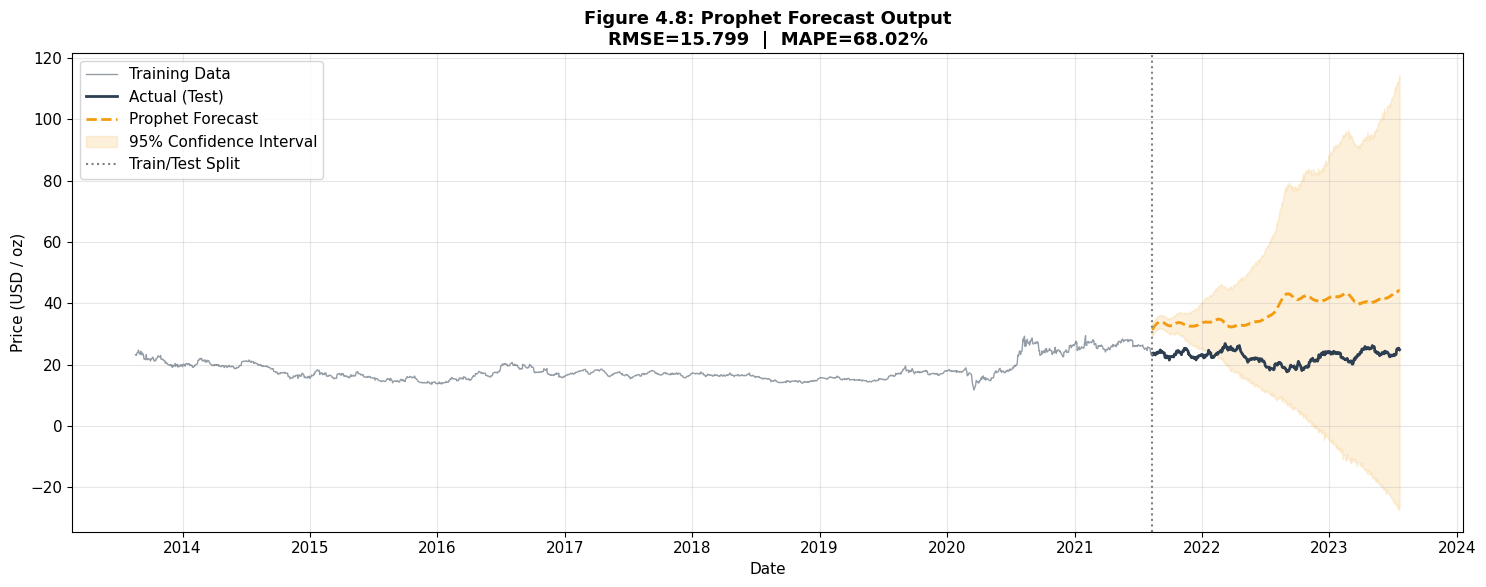

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6))

# Training actual
ax.plot(prophet_train['ds'], prophet_train['y'], color=COLORS['actual'], linewidth=1, alpha=0.5, label='Training Data')

# Test actual
test_dates = test_df['Date'].values[:min_len]
ax.plot(test_dates, prophet_actual, color=COLORS['actual'], linewidth=2, label='Actual (Test)')

# Prophet prediction
ax.plot(test_dates, prophet_pred, color=COLORS['prophet'], linewidth=2, linestyle='--', label='Prophet Forecast')

# Confidence interval on test window
test_fc = prophet_test_forecast[:min_len]
ax.fill_between(test_fc['ds'].values,
                test_fc['yhat_lower'].values,
                test_fc['yhat_upper'].values,
                alpha=0.15, color=COLORS['prophet'], label='95% Confidence Interval')

ax.axvline(x=train_df['Date'].iloc[-1], color='grey', linestyle=':', linewidth=1.5, label='Train/Test Split')
ax.set_title(f'Figure 4.8: Prophet Forecast Output\nRMSE={prophet_rmse:.3f}  |  MAPE={prophet_mape:.2f}%', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD / oz)')
ax.legend()
plt.tight_layout()
plt.savefig('fig4_8_prophet_forecast.png', dpi=150)
plt.show()

### Figure 4.9 — Prophet Trend and Seasonality Components

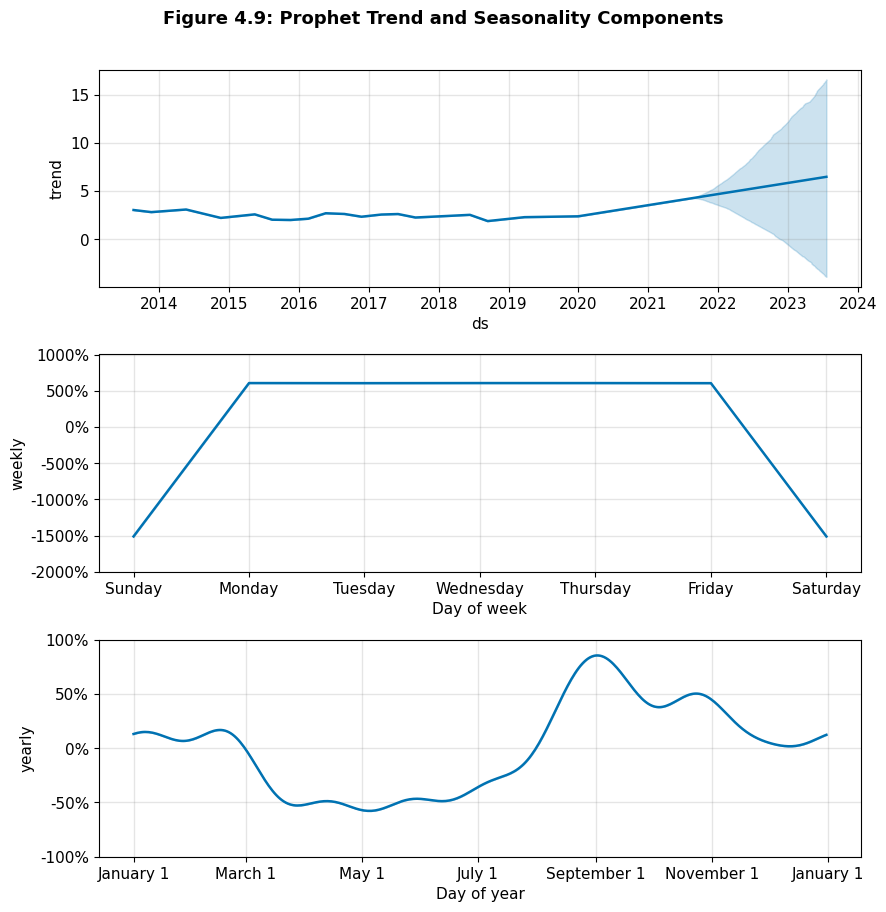

In [ ]:
fig = prophet_model.plot_components(prophet_forecast)
fig.suptitle('Figure 4.9: Prophet Trend and Seasonality Components', fontweight='bold', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig('fig4_9_prophet_components.png', dpi=150)
plt.show()

---
## 6. Model 3 — LSTM Neural Network (Chapter 3.5.3 & Figures 4.10, 4.11)

In [ ]:
# ─── Sliding Window Dataset Generator ────────────────────────────────────────
LOOKBACK = 60  # number of past time steps used as input

def create_sequences(data, lookback=60):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

# Scale full series (fit on training only)
lstm_scaler  = MinMaxScaler(feature_range=(0, 1))
train_scaled = lstm_scaler.fit_transform(train_df[['Close']])
test_scaled  = lstm_scaler.transform(test_df[['Close']])

# Create sequences
X_train, y_train = create_sequences(train_scaled, LOOKBACK)

# For test: prepend last LOOKBACK rows of training
full_scaled  = np.concatenate([train_scaled, test_scaled], axis=0)
X_test_full  = full_scaled[len(train_scaled) - LOOKBACK:]
X_test, y_test_lstm = create_sequences(X_test_full, LOOKBACK)

# Reshape → [samples, time steps, features]
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test  = X_test.reshape(X_test.shape[0],  X_test.shape[1],  1)

print(f'X_train shape : {X_train.shape}')
print(f'X_test  shape : {X_test.shape}')
print(f'Lookback window: {LOOKBACK} days')

X_train shape : (1971, 60, 1)
X_test  shape : (508, 60, 1)
Lookback window: 60 days


In [ ]:
# ─── Build LSTM Architecture ──────────────────────────────────────────────────
tf.random.set_seed(42)

lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(LOOKBACK, 1)),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mean_squared_error'
)

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,033 (203.25 KB)

 Trainable params: 52,033 (203.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ─── Train LSTM Model ─────────────────────────────────────────────────────────
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)
print(f'\nTraining completed. Best epoch: {np.argmin(lstm_history.history["val_loss"])+1}')

Epoch 1/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - loss: 0.0110 - val_loss: 0.0099
Epoch 2/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 0.0025 - val_loss: 0.0044
Epoch 3/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 0.0021 - val_loss: 0.0035
Epoch 4/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - loss: 0.0019 - val_loss: 0.0055
Epoch 5/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - loss: 0.0017 - val_loss: 0.0035
Epoch 6/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - loss: 0.0017 - val_loss: 0.0076
Epoch 7/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - loss: 0.0016 - val_loss: 0.0035
Epoch 8/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - loss: 0.0014 - val_loss: 0.0019
Epoch 9/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 0.0013 - val_loss: 0.0036
Epoch 10/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0011 - val_loss: 0.0027
Epoch 11/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 0.0012 - val_loss: 0.0031
Epoch 12/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step

In [ ]:
# ─── LSTM Predictions ─────────────────────────────────────────────────────────
lstm_pred_scaled = lstm_model.predict(X_test)
lstm_pred = lstm_scaler.inverse_transform(lstm_pred_scaled).flatten()

# Align lengths
lstm_actual = test_df['Close'].values[:len(lstm_pred)]
lstm_dates  = test_df['Date'].values[:len(lstm_pred)]

lstm_rmse = np.sqrt(mean_squared_error(lstm_actual, lstm_pred))
lstm_mape = mean_absolute_percentage_error(lstm_actual, lstm_pred) * 100
print(f'\n══ LSTM Performance ══')
print(f'  RMSE : {lstm_rmse:.4f}')
print(f'  MAPE : {lstm_mape:.2f}%')

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step

══ LSTM Performance ══
  RMSE : 0.6884
  MAPE : 2.40%


### Figure 4.10 — LSTM Predicted vs Actual Values

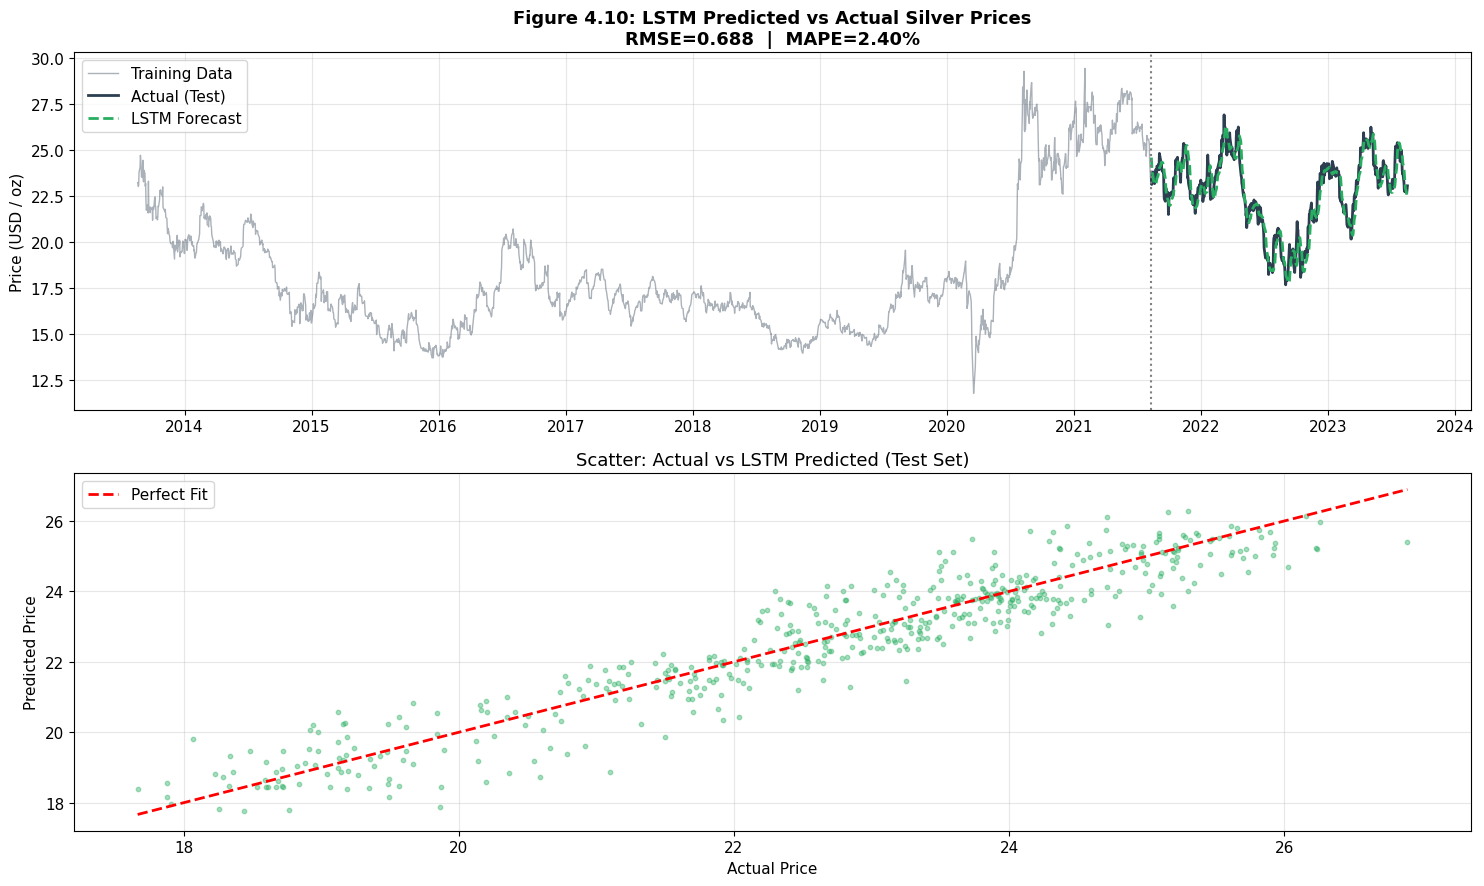

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(15, 9))

# Full series + prediction
axes[0].plot(train_df['Date'], train_df['Close'], color=COLORS['actual'], linewidth=1, alpha=0.4, label='Training Data')
axes[0].plot(lstm_dates, lstm_actual, color=COLORS['actual'],  linewidth=2,   label='Actual (Test)')
axes[0].plot(lstm_dates, lstm_pred,   color=COLORS['lstm'],    linewidth=2, linestyle='--', label='LSTM Forecast')
axes[0].axvline(x=train_df['Date'].iloc[-1], color='grey', linestyle=':', linewidth=1.5)
axes[0].set_title(f'Figure 4.10: LSTM Predicted vs Actual Silver Prices\nRMSE={lstm_rmse:.3f}  |  MAPE={lstm_mape:.2f}%', fontweight='bold')
axes[0].set_ylabel('Price (USD / oz)')
axes[0].legend()

# Scatter: actual vs predicted
axes[1].scatter(lstm_actual, lstm_pred, alpha=0.4, color=COLORS['lstm'], s=10)
lims = [min(lstm_actual.min(), lstm_pred.min()), max(lstm_actual.max(), lstm_pred.max())]
axes[1].plot(lims, lims, 'r--', linewidth=2, label='Perfect Fit')
axes[1].set_title('Scatter: Actual vs LSTM Predicted (Test Set)')
axes[1].set_xlabel('Actual Price')
axes[1].set_ylabel('Predicted Price')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig4_10_lstm_predicted.png', dpi=150)
plt.show()

### Figure 4.11 — LSTM Training Loss Curve

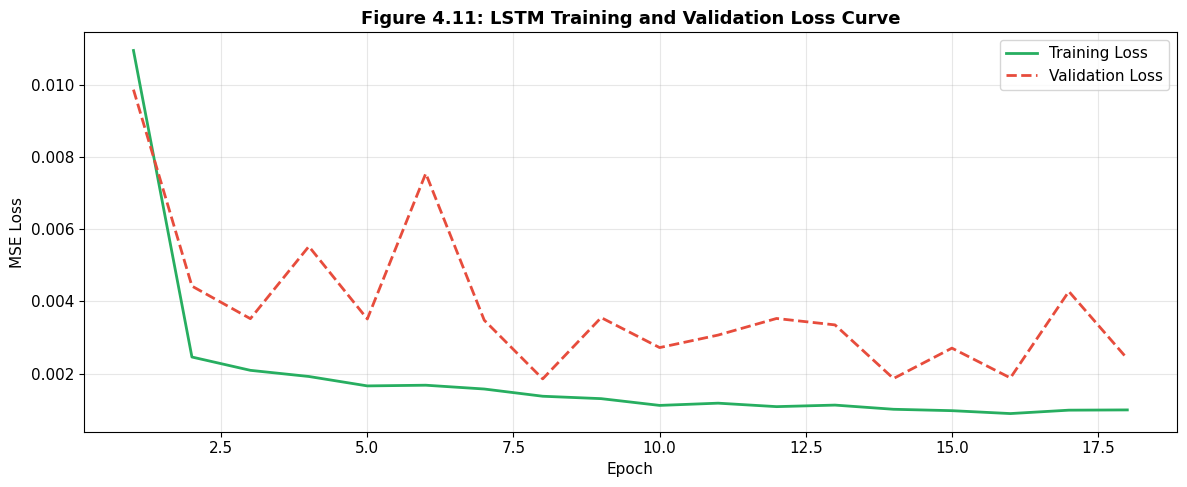

Best validation loss: 0.001852 at epoch 8


In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
epochs_range = range(1, len(lstm_history.history['loss'])+1)

ax.plot(epochs_range, lstm_history.history['loss'],     color=COLORS['lstm'],  linewidth=2, label='Training Loss')
ax.plot(epochs_range, lstm_history.history['val_loss'], color='#e74c3c',        linewidth=2, linestyle='--', label='Validation Loss')
ax.set_title('Figure 4.11: LSTM Training and Validation Loss Curve', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend()
plt.tight_layout()
plt.savefig('fig4_11_lstm_loss.png', dpi=150)
plt.show()
print(f'Best validation loss: {min(lstm_history.history["val_loss"]):.6f} at epoch {np.argmin(lstm_history.history["val_loss"])+1}')

---
## 7. Model 4 — Hybrid ARIMA-LSTM (Chapter 3.5.4 & Figure 4.12)

Step 1: Fit ARIMA on training data and extract residuals...
  Residuals shape : (2031,)
  Residuals mean  : 0.0115
  Residuals std   : 0.6255


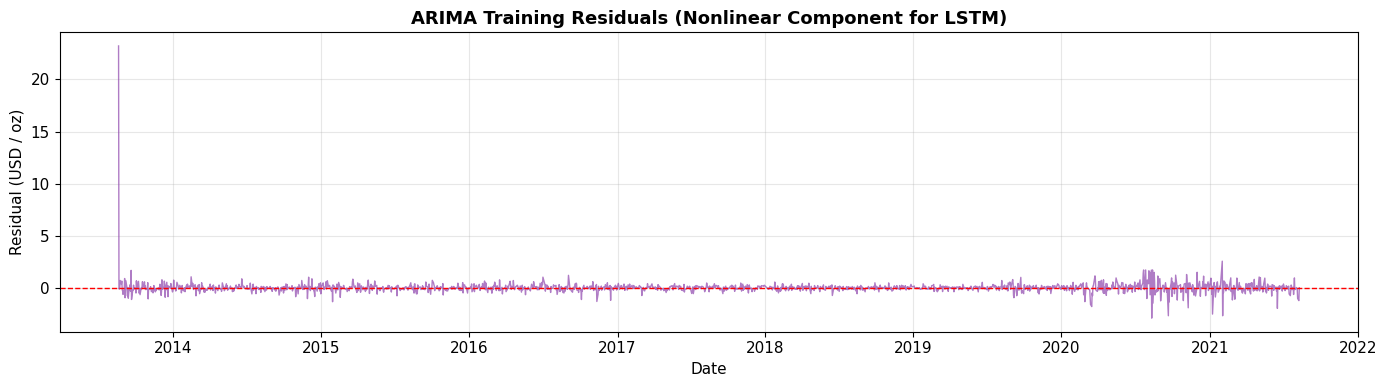

In [ ]:
# ─── Hybrid Strategy ──────────────────────────────────────────────────────────
# Step 1: ARIMA captures linear component
# Step 2: Residuals (nonlinear component) fed to LSTM
# Step 3: Final forecast = ARIMA forecast + LSTM residual forecast

print('Step 1: Fit ARIMA on training data and extract residuals...')
arima_train_model = ARIMA(train_df['Close'], order=best_order).fit()
arima_train_fitted = arima_train_model.fittedvalues

# Residuals = actual - ARIMA fitted (nonlinear component)
arima_residuals = train_df['Close'].values - arima_train_fitted.values
arima_residuals = pd.Series(arima_residuals).fillna(0).values

print(f'  Residuals shape : {arima_residuals.shape}')
print(f'  Residuals mean  : {arima_residuals.mean():.4f}')
print(f'  Residuals std   : {arima_residuals.std():.4f}')

# Plot residuals
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train_df['Date'], arima_residuals, color='#8e44ad', linewidth=1, alpha=0.7)
ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.set_title('ARIMA Training Residuals (Nonlinear Component for LSTM)', fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Residual (USD / oz)')
plt.tight_layout()
plt.show()

In [ ]:
# ─── Step 2: Train LSTM on ARIMA Residuals ────────────────────────────────────
print('Step 2: Train LSTM on ARIMA residuals...')

res_scaler = MinMaxScaler(feature_range=(-1, 1))
residuals_scaled = res_scaler.fit_transform(arima_residuals.reshape(-1, 1))

def create_sequences_1d(data, lookback=60):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_res, y_res = create_sequences_1d(residuals_scaled, LOOKBACK)
X_res = X_res.reshape(X_res.shape[0], X_res.shape[1], 1)

# LSTM for residuals
tf.random.set_seed(42)
lstm_res_model = Sequential([
    LSTM(32, return_sequences=True, input_shape=(LOOKBACK, 1)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])
lstm_res_model.compile(optimizer='adam', loss='mse')

early2 = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=0)
lstm_res_model.fit(
    X_res, y_res,
    epochs=80,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early2],
    verbose=1
)
print('LSTM residual model trained.')

Step 2: Train LSTM on ARIMA residuals...
Epoch 1/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - loss: 0.0648 - val_loss: 0.0030
Epoch 2/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0079 - val_loss: 0.0023
Epoch 3/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0062 - val_loss: 0.0037
Epoch 4/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - loss: 0.0046 - val_loss: 0.0031
Epoch 5/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - loss: 0.0042 - val_loss: 0.0041
Epoch 6/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0033 - val_loss: 0.0028
Epoch 7/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0030 - val_loss: 0.0034
Epoch 8/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 0.0027 - val_loss: 0.0029
Epoch 9/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 0.0024 - val_loss: 0.0035
Epoch 10/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0023 - val_loss: 0.0030
LSTM residual model trained.


In [ ]:
# ─── Step 3: Hybrid Forecasting on Test Set ───────────────────────────────────
print('Step 3: Generate hybrid forecasts on test set...')

hybrid_preds = []
history_vals = list(train_df['Close'])
res_history  = list(arima_residuals)

for i in range(n_test):
    # ARIMA linear forecast
    arima_m = ARIMA(history_vals, order=best_order).fit()
    arima_fc = arima_m.forecast(steps=1)[0]

    # LSTM residual forecast
    if len(res_history) >= LOOKBACK:
        res_seq = np.array(res_history[-LOOKBACK:]).reshape(-1, 1)
        res_seq_scaled = res_scaler.transform(res_seq)
        res_seq_in = res_seq_scaled.reshape(1, LOOKBACK, 1)
        res_fc_scaled = lstm_res_model.predict(res_seq_in, verbose=0)
        res_fc = res_scaler.inverse_transform(res_fc_scaled)[0, 0]
    else:
        res_fc = 0.0

    # Combine
    hybrid_fc = arima_fc + res_fc
    hybrid_preds.append(hybrid_fc)

    # Update histories
    actual_val = test_df['Close'].iloc[i]
    history_vals.append(actual_val)
    new_res = actual_val - arima_fc
    res_history.append(new_res)

    if (i+1) % 100 == 0:
        print(f'  Hybrid forecast: step {i+1}/{n_test}')

hybrid_pred   = np.array(hybrid_preds)
hybrid_actual = test_df['Close'].values
hybrid_dates  = test_df['Date'].values

hybrid_rmse = np.sqrt(mean_squared_error(hybrid_actual, hybrid_pred))
hybrid_mape = mean_absolute_percentage_error(hybrid_actual, hybrid_pred) * 100
print(f'\n══ Hybrid ARIMA-LSTM Performance ══')
print(f'  RMSE : {hybrid_rmse:.4f}')
print(f'  MAPE : {hybrid_mape:.2f}%')

Step 3: Generate hybrid forecasts on test set...
  Hybrid forecast: step 100/508
  Hybrid forecast: step 200/508
  Hybrid forecast: step 300/508
  Hybrid forecast: step 400/508
  Hybrid forecast: step 500/508

══ Hybrid ARIMA-LSTM Performance ══
  RMSE : 0.4701
  MAPE : 1.64%


### Figure 4.12 — Hybrid ARIMA-LSTM Forecast vs Actual Values

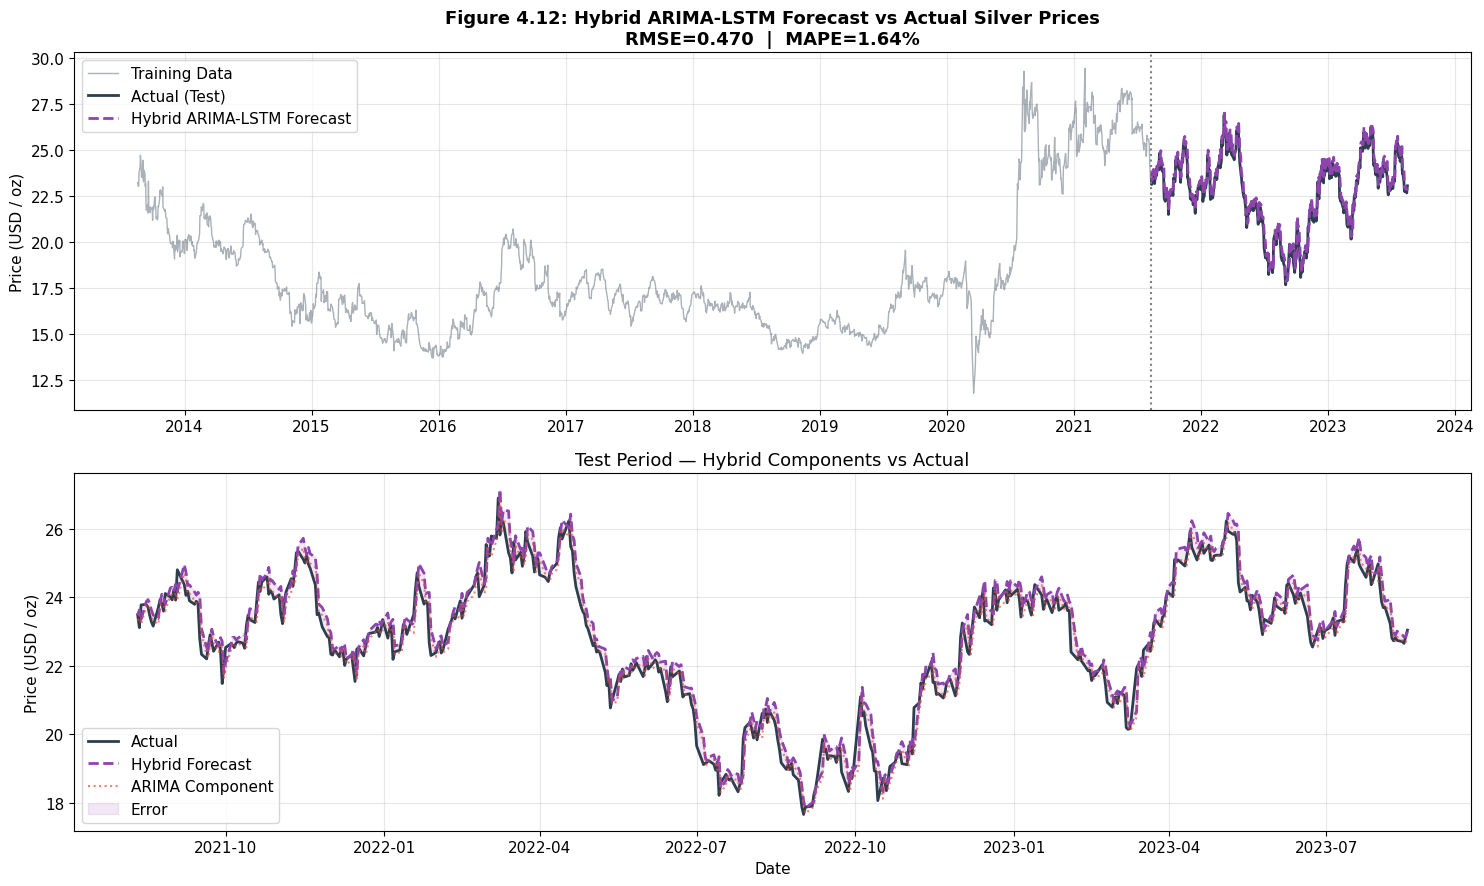

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(15, 9))

# Full view
axes[0].plot(train_df['Date'], train_df['Close'], color=COLORS['actual'], linewidth=1, alpha=0.4, label='Training Data')
axes[0].plot(hybrid_dates, hybrid_actual, color=COLORS['actual'], linewidth=2, label='Actual (Test)')
axes[0].plot(hybrid_dates, hybrid_pred,   color=COLORS['hybrid'], linewidth=2, linestyle='--', label='Hybrid ARIMA-LSTM Forecast')
axes[0].axvline(x=train_df['Date'].iloc[-1], color='grey', linestyle=':', linewidth=1.5)
axes[0].set_title(f'Figure 4.12: Hybrid ARIMA-LSTM Forecast vs Actual Silver Prices\nRMSE={hybrid_rmse:.3f}  |  MAPE={hybrid_mape:.2f}%', fontweight='bold')
axes[0].set_ylabel('Price (USD / oz)')
axes[0].legend()

# Test period with component breakdown
axes[1].plot(hybrid_dates, hybrid_actual, color=COLORS['actual'],  linewidth=2, label='Actual')
axes[1].plot(hybrid_dates, hybrid_pred,   color=COLORS['hybrid'],  linewidth=2, linestyle='--', label='Hybrid Forecast')
axes[1].plot(hybrid_dates, arima_pred,    color=COLORS['arima'],   linewidth=1.5, linestyle=':',  alpha=0.7, label='ARIMA Component')
axes[1].fill_between(hybrid_dates, hybrid_actual, hybrid_pred, alpha=0.12, color=COLORS['hybrid'], label='Error')
axes[1].set_title('Test Period — Hybrid Components vs Actual')
axes[1].set_ylabel('Price (USD / oz)')
axes[1].set_xlabel('Date')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig4_12_hybrid_forecast.png', dpi=150)
plt.show()

---
## 8. Comparative Performance Analysis (Chapter 4.5)

In [ ]:
# ─── Performance Summary Table ────────────────────────────────────────────────
performance = pd.DataFrame({
    'Model': ['ARIMA', 'Prophet', 'LSTM', 'Hybrid ARIMA-LSTM'],
    'RMSE':  [arima_rmse, prophet_rmse, lstm_rmse, hybrid_rmse],
    'MAPE (%)': [arima_mape, prophet_mape, lstm_mape, hybrid_mape],
})
performance['RMSE'] = performance['RMSE'].round(4)
performance['MAPE (%)'] = performance['MAPE (%)'].round(2)
performance['Rank (RMSE)'] = performance['RMSE'].rank().astype(int)
performance['Rank (MAPE)'] = performance['MAPE (%)'].rank().astype(int)

print('═══ Model Performance Summary ═══')
print(performance.to_string(index=False))

═══ Model Performance Summary ═══
            Model    RMSE  MAPE (%)  Rank (RMSE)  Rank (MAPE)
            ARIMA  0.4049      1.39            1            1
          Prophet 15.7989     68.02            4            4
             LSTM  0.6884      2.40            3            3
Hybrid ARIMA-LSTM  0.4701      1.64            2            2


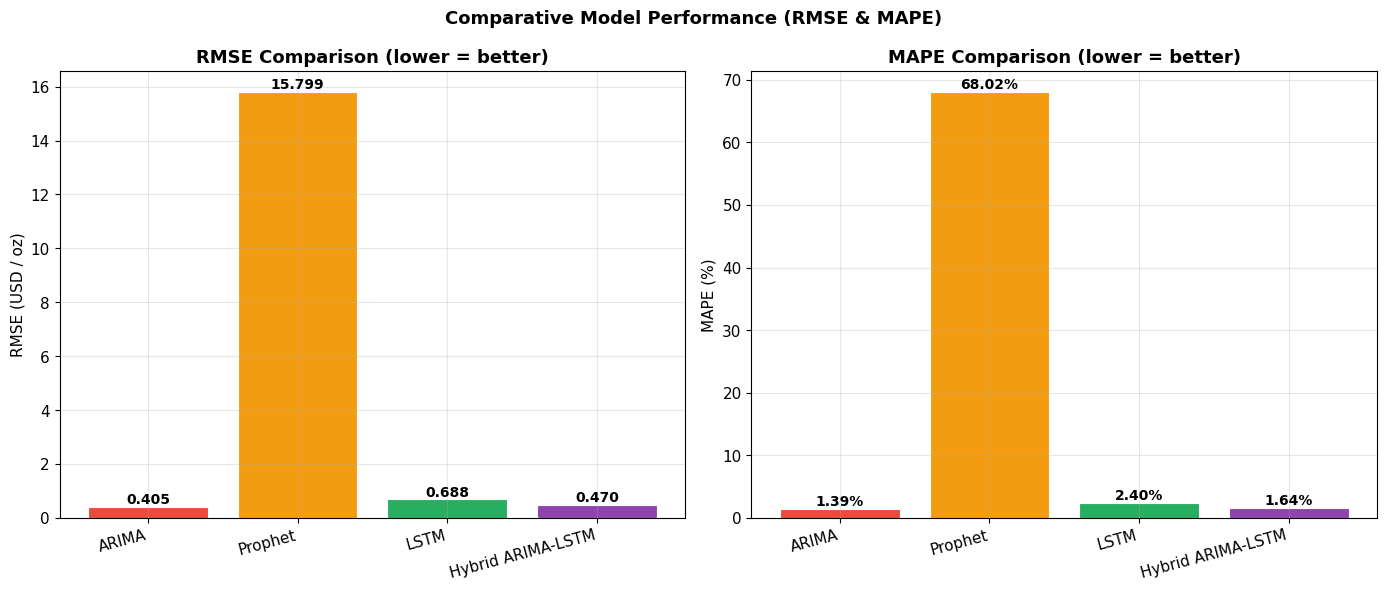

In [ ]:
# ─── Figure: Comparative Bar Chart ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

model_names  = performance['Model']
model_colors = [COLORS['arima'], COLORS['prophet'], COLORS['lstm'], COLORS['hybrid']]

bars1 = axes[0].bar(model_names, performance['RMSE'], color=model_colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('RMSE Comparison (lower = better)', fontweight='bold')
axes[0].set_ylabel('RMSE (USD / oz)')
axes[0].set_xticklabels(model_names, rotation=15, ha='right')
for bar, val in zip(bars1, performance['RMSE']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

bars2 = axes[1].bar(model_names, performance['MAPE (%)'], color=model_colors, edgecolor='white', linewidth=0.8)
axes[1].set_title('MAPE Comparison (lower = better)', fontweight='bold')
axes[1].set_ylabel('MAPE (%)')
axes[1].set_xticklabels(model_names, rotation=15, ha='right')
for bar, val in zip(bars2, performance['MAPE (%)']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Comparative Model Performance (RMSE & MAPE)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('fig_comparative_bar.png', dpi=150)
plt.show()

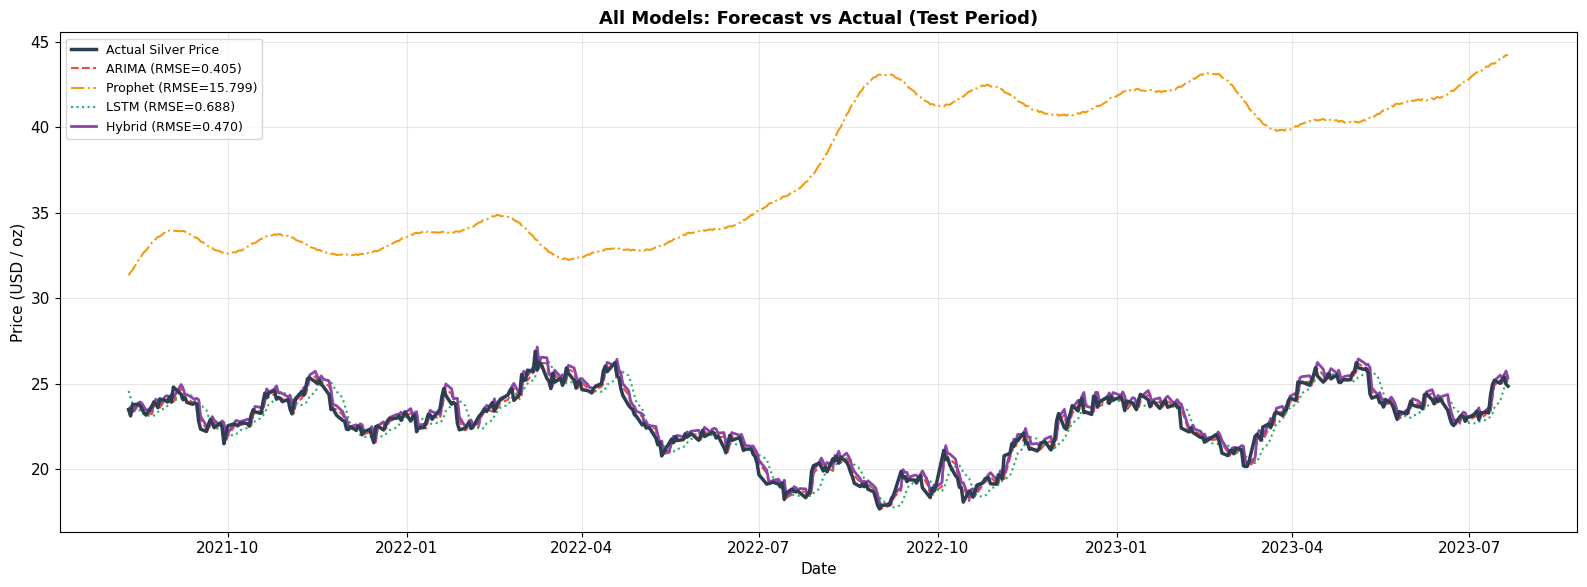

In [ ]:
# ─── All Models Overlaid on Test Period ───────────────────────────────────────
common_len = min(len(arima_pred), len(prophet_pred), len(lstm_pred), len(hybrid_pred))
common_dates = test_df['Date'].values[:common_len]
actual_common = test_df['Close'].values[:common_len]

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(common_dates, actual_common,         color=COLORS['actual'],  linewidth=2.5, label='Actual Silver Price', zorder=5)
ax.plot(common_dates, arima_pred[:common_len],   color=COLORS['arima'],   linewidth=1.5, linestyle='--',  label=f'ARIMA (RMSE={arima_rmse:.3f})')
ax.plot(common_dates, prophet_pred[:common_len], color=COLORS['prophet'], linewidth=1.5, linestyle='-.',  label=f'Prophet (RMSE={prophet_rmse:.3f})')
ax.plot(common_dates, lstm_pred[:common_len],    color=COLORS['lstm'],    linewidth=1.5, linestyle=':',   label=f'LSTM (RMSE={lstm_rmse:.3f})')
ax.plot(common_dates, hybrid_pred[:common_len],  color=COLORS['hybrid'],  linewidth=2,   linestyle='-',   label=f'Hybrid (RMSE={hybrid_rmse:.3f})')

ax.set_title('All Models: Forecast vs Actual (Test Period)', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD / oz)')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('fig_all_models_overlay.png', dpi=150)
plt.show()

---
## 9. Model Behaviour Under Market Volatility (Chapter 4.6)

In [ ]:
# ─── Error Analysis During High-Volatility Periods ────────────────────────────
test_analysis = pd.DataFrame({
    'Date':   test_df['Date'].values[:common_len],
    'Actual': actual_common,
    'ARIMA':  arima_pred[:common_len],
    'Prophet':prophet_pred[:common_len],
    'LSTM':   lstm_pred[:common_len],
    'Hybrid': hybrid_pred[:common_len]
})

# Absolute errors
for m in ['ARIMA', 'Prophet', 'LSTM', 'Hybrid']:
    test_analysis[f'{m}_err'] = np.abs(test_analysis['Actual'] - test_analysis[m])

# Rolling volatility of actual
test_analysis['Volatility'] = pd.Series(actual_common).rolling(20).std().values

# High volatility periods (top 25%)
vol_threshold = test_analysis['Volatility'].quantile(0.75)
high_vol = test_analysis[test_analysis['Volatility'] > vol_threshold]
low_vol  = test_analysis[test_analysis['Volatility'] <= vol_threshold]

print('═══ Error by Market Regime ═══')
print('\nHigh Volatility Periods — Mean Absolute Error:')
for m in ['ARIMA', 'Prophet', 'LSTM', 'Hybrid']:
    print(f'  {m:<20}: {high_vol[f"{m}_err"].mean():.4f}')

print('\nLow Volatility Periods — Mean Absolute Error:')
for m in ['ARIMA', 'Prophet', 'LSTM', 'Hybrid']:
    print(f'  {m:<20}: {low_vol[f"{m}_err"].mean():.4f}')

═══ Error by Market Regime ═══

High Volatility Periods — Mean Absolute Error:
  ARIMA               : 0.3071
  Prophet             : 15.7134
  LSTM                : 0.4644
  Hybrid              : 0.3485

Low Volatility Periods — Mean Absolute Error:
  ARIMA               : 0.3196
  Prophet             : 15.0086
  LSTM                : 0.5697
  Hybrid              : 0.3799


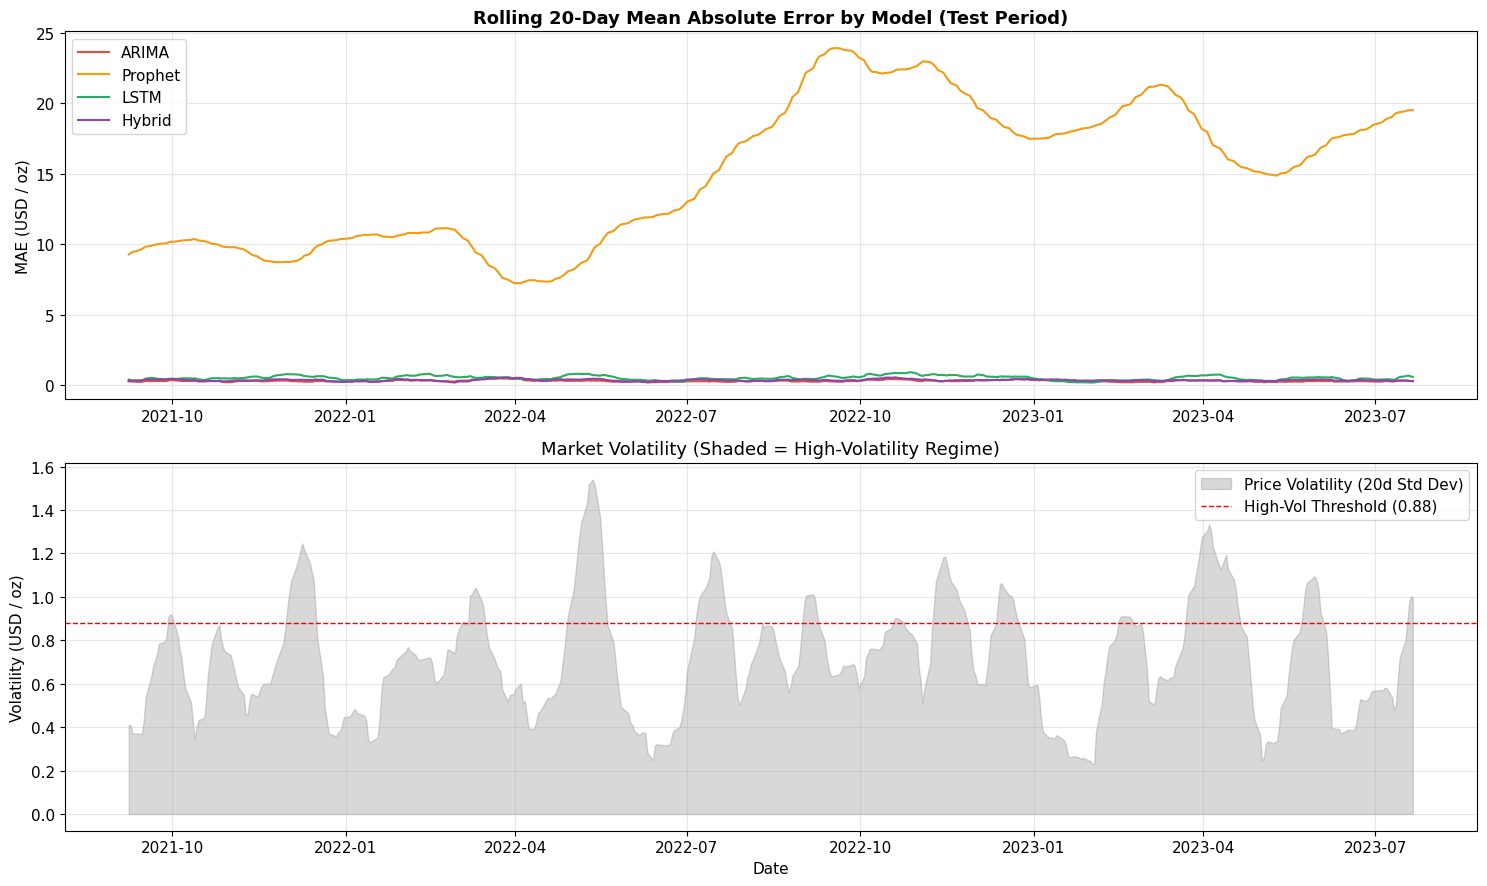

In [ ]:
# ─── Volatility-Error Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(15, 9))

# Top: rolling errors
for m, c in zip(['ARIMA','Prophet','LSTM','Hybrid'], [COLORS['arima'], COLORS['prophet'], COLORS['lstm'], COLORS['hybrid']]):
    rolling_err = test_analysis[f'{m}_err'].rolling(20).mean()
    axes[0].plot(test_analysis['Date'], rolling_err, color=c, linewidth=1.5, label=m)
axes[0].set_title('Rolling 20-Day Mean Absolute Error by Model (Test Period)', fontweight='bold')
axes[0].set_ylabel('MAE (USD / oz)')
axes[0].legend()

# Bottom: volatility overlay
axes[1].fill_between(test_analysis['Date'], 0, test_analysis['Volatility'], alpha=0.3, color='grey', label='Price Volatility (20d Std Dev)')
axes[1].axhline(y=vol_threshold, color='red', linestyle='--', linewidth=1, label=f'High-Vol Threshold ({vol_threshold:.2f})')
axes[1].set_title('Market Volatility (Shaded = High-Volatility Regime)')
axes[1].set_ylabel('Volatility (USD / oz)')
axes[1].set_xlabel('Date')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_volatility_analysis.png', dpi=150)
plt.show()

---
## 10. Chapter Summary & Export Results

In [ ]:
# ─── Export Performance Table ─────────────────────────────────────────────────
performance.to_csv('model_performance_summary.csv', index=False)
test_analysis.to_csv('test_predictions_all_models.csv', index=False)

print('Results exported:')
print('  model_performance_summary.csv')
print('  test_predictions_all_models.csv')

Results exported:
  model_performance_summary.csv
  test_predictions_all_models.csv


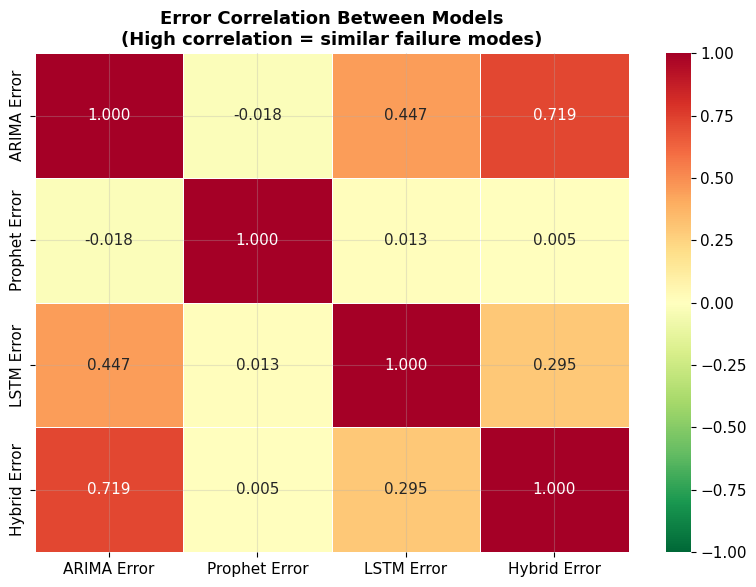

In [ ]:
# ─── Final Heatmap: Error Correlation ─────────────────────────────────────────
error_df = pd.DataFrame({
    'ARIMA Error':   np.abs(test_analysis['Actual'] - test_analysis['ARIMA']),
    'Prophet Error': np.abs(test_analysis['Actual'] - test_analysis['Prophet']),
    'LSTM Error':    np.abs(test_analysis['Actual'] - test_analysis['LSTM']),
    'Hybrid Error':  np.abs(test_analysis['Actual'] - test_analysis['Hybrid'])
})

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(error_df.corr(), annot=True, fmt='.3f', cmap='RdYlGn_r', ax=ax,
            center=0, vmin=-1, vmax=1, linewidths=0.5)
ax.set_title('Error Correlation Between Models\n(High correlation = similar failure modes)', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_error_correlation.png', dpi=150)
plt.show()

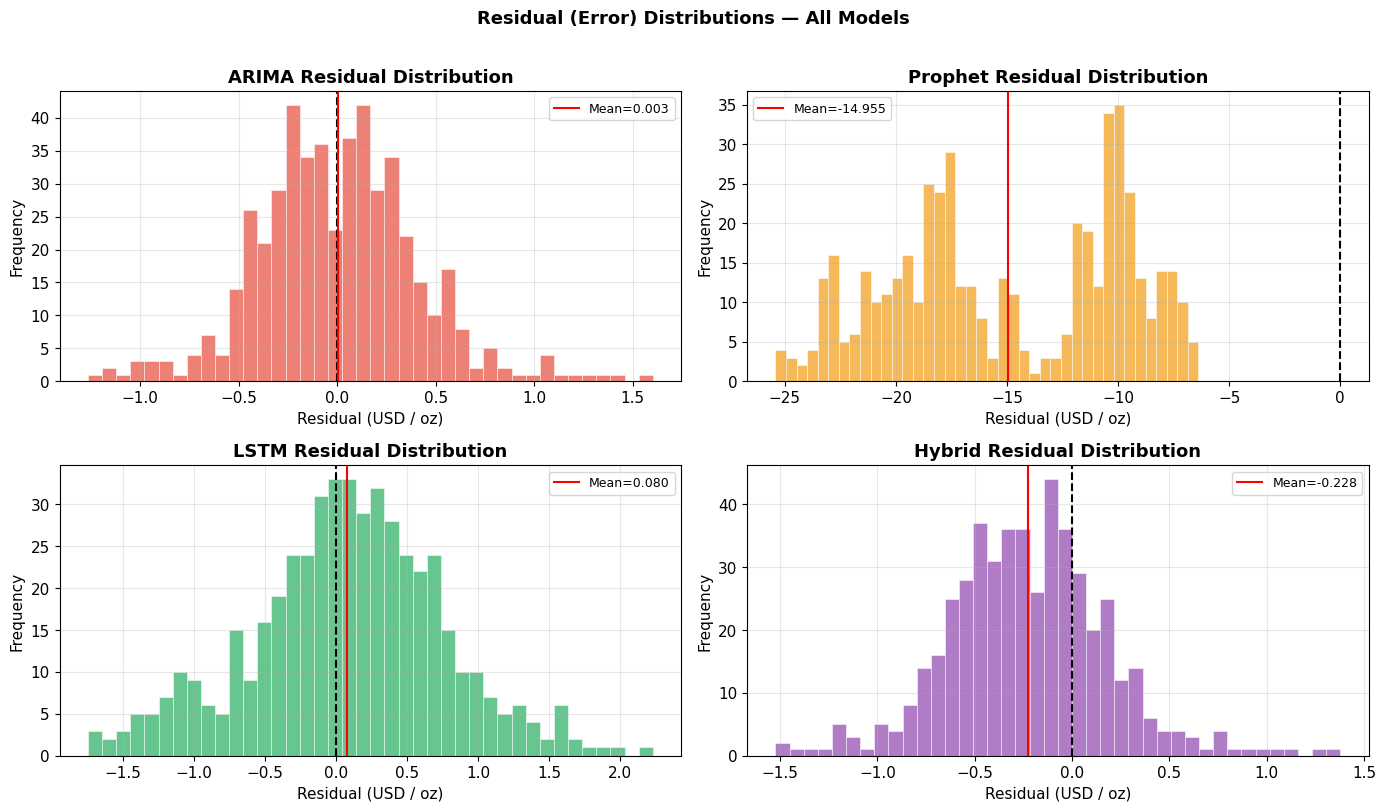

In [ ]:
# ─── Residual Distribution Comparison ────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

models_info = [
    ('ARIMA',   arima_pred[:common_len],   COLORS['arima']),
    ('Prophet', prophet_pred[:common_len], COLORS['prophet']),
    ('LSTM',    lstm_pred[:common_len],    COLORS['lstm']),
    ('Hybrid',  hybrid_pred[:common_len],  COLORS['hybrid'])
]

for ax, (name, pred, color) in zip(axes.flat, models_info):
    residuals = actual_common - pred
    ax.hist(residuals, bins=40, color=color, alpha=0.7, edgecolor='white', linewidth=0.5)
    ax.axvline(0, color='black', linestyle='--', linewidth=1.5)
    ax.axvline(residuals.mean(), color='red', linestyle='-', linewidth=1.5, label=f'Mean={residuals.mean():.3f}')
    ax.set_title(f'{name} Residual Distribution', fontweight='bold')
    ax.set_xlabel('Residual (USD / oz)')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)

plt.suptitle('Residual (Error) Distributions — All Models', fontweight='bold', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig('fig_residual_distributions.png', dpi=150)
plt.show()

In [ ]:
# ─── Final Summary Print ──────────────────────────────────────────────────────
print('═══════════════════════════════════════════════════════════════')
print('     DISSERTATION — FINAL MODEL PERFORMANCE SUMMARY')
print('═══════════════════════════════════════════════════════════════')
print(f'  Dataset  : Silver prices  |  ~10 years daily  |  {len(df)} records')
print(f'  Period   : {df["Date"].min().date()} → {df["Date"].max().date()}')
print(f'  Train/Test Split : 80% / 20%')
print(f'  Lookback : {LOOKBACK} days (LSTM)')
print(f'  ARIMA order : {best_order}')
print()
print(performance[['Model','RMSE','MAPE (%)','Rank (RMSE)','Rank (MAPE)']].to_string(index=False))
print()
best = performance.loc[performance['RMSE'].idxmin()]
print(f'  ★ Best Model: {best["Model"]}  (RMSE={best["RMSE"]:.4f},  MAPE={best["MAPE (%)"]:.2f}%)')
print('═══════════════════════════════════════════════════════════════')
print('\nAll figures saved. Notebook complete.')

═══════════════════════════════════════════════════════════════
     DISSERTATION — FINAL MODEL PERFORMANCE SUMMARY
═══════════════════════════════════════════════════════════════
  Dataset  : Silver prices  |  ~10 years daily  |  2539 records
  Period   : 2013-08-19 → 2023-08-17
  Train/Test Split : 80% / 20%
  Lookback : 60 days (LSTM)
  ARIMA order : (3, 1, 2)

            Model    RMSE  MAPE (%)  Rank (RMSE)  Rank (MAPE)
            ARIMA  0.4049      1.39            1            1
          Prophet 15.7989     68.02            4            4
             LSTM  0.6884      2.40            3            3
Hybrid ARIMA-LSTM  0.4701      1.64            2            2

  ★ Best Model: ARIMA  (RMSE=0.4049,  MAPE=1.39%)
═══════════════════════════════════════════════════════════════

All figures saved. Notebook complete.
